In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np
from sklearn.datasets import load_iris

--- Ejecutando función para Iris dataset ---


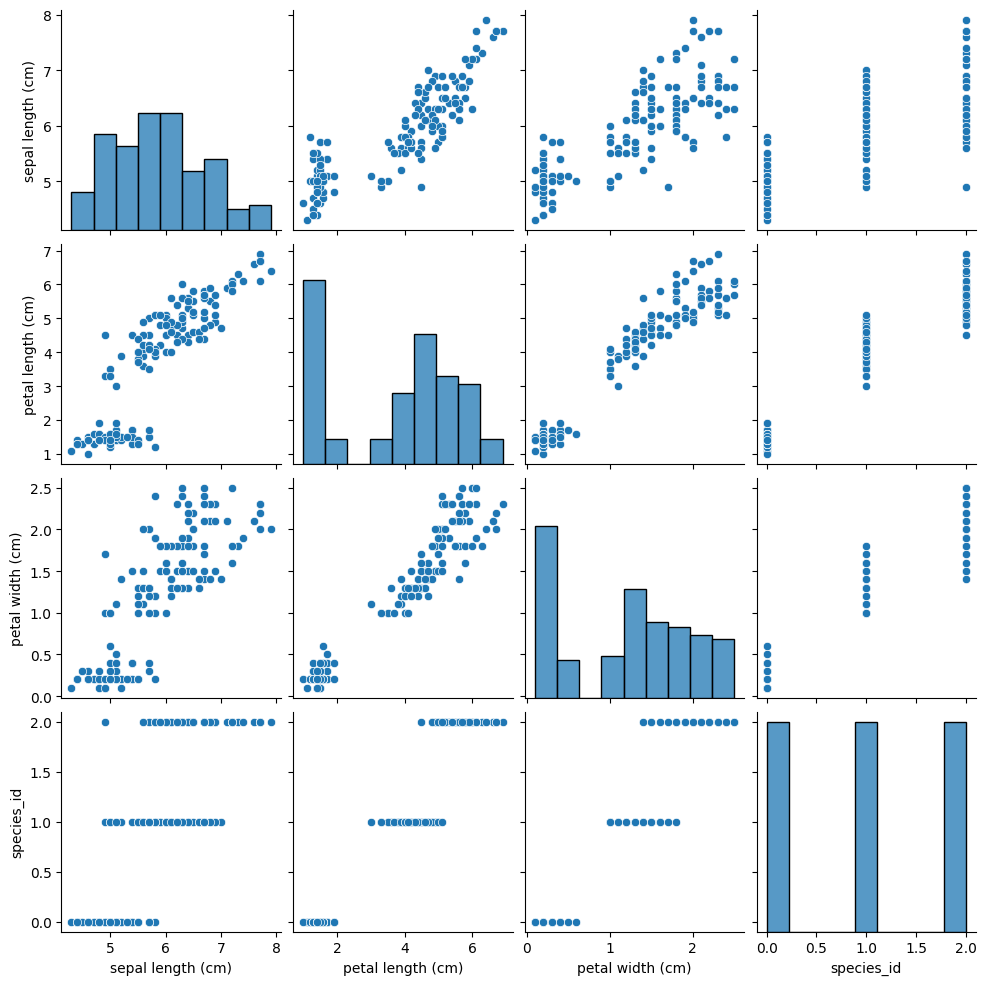


Columnas del Iris dataset seleccionadas que cumplen los criterios:
['petal length (cm)', 'petal width (cm)', 'species_id']


In [ ]:
def plot_features_num_regression(df, target_col="", columns=[], umbral_corr=0, pvalue=None):
    """
    Esta función filtra variables numéricas de un DataFrame basándose en la correlación 
    con una columna objetivo y un umbral de p-value, y genera pairplots.
    """
    
    # --- 1. Chequeo de valores de entrada ---
    if target_col not in df.columns:
        print(f"Error: La columna target_col '{target_col}' no se encuentra en el DataFrame.")
        return []

    # Si la lista columns está vacía, usar todas las columnas numéricas excepto target_col
    if not columns:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        columns = [col for col in numeric_cols if col != target_col]

    valid_columns = []
    for col in columns:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            valid_columns.append(col)
        else:
            print(f"Advertencia: La columna '{col}' no es válida o no es numérica y será ignorada.")
    
    if not valid_columns:
        print("No hay columnas numéricas válidas para analizar.")
        return []
    
    # --- 2. Filtrado de columnas basado en correlación y p-value ---
    selected_features = []
    for col in valid_columns:
        # Calcular correlación de Pearson y p-value
        temp_df = df[[target_col, col]].dropna()
        if len(temp_df) < 2:
            continue
            
        r, p = pearsonr(temp_df[target_col], temp_df[col])
        
        # Verificar condiciones de umbral de correlación y p-value
        corr_condition = abs(r) > umbral_corr
        # El nivel de significación es 1-pvalue, por lo que p debe ser < (1 - (1-alpha)) = alpha, si pvalue es alpha
        pvalue_condition = True if pvalue is None else p < pvalue 

        if corr_condition and pvalue_condition:
            selected_features.append(col)

    if not selected_features:
        print(f"No se encontraron columnas que cumplan los criterios de correlación (>{umbral_corr}) y/o p-value.")
        return []

    # --- 3. Visualización (Extra: múltiples pairplots) ---
    features_to_plot = [target_col] + selected_features
    max_cols_per_plot = 4 # 5 incluyendo target_col
    
    if len(selected_features) > max_cols_per_plot:
        print(f"Se encontraron {len(selected_features)} columnas relevantes. Generando múltiples pairplots.")
        for i in range(0, len(selected_features), max_cols_per_plot):
            subset_features = [target_col] + selected_features[i:i + max_cols_per_plot]
            sns.pairplot(df[subset_features])
            plt.show()
    else:
        sns.pairplot(df[features_to_plot])
        plt.show()

    # Devolver los valores de "columns" que cumplen con las condiciones
    return selected_features

#### **Answer:**
#El código anterior define la función `plot_features_num_regression` según las especificaciones.

#A continuación, se muestra un ejemplo de cómo cargar el dataset Iris y utilizar la función para identificar y visualizar las columnas que tienen una alta correlación (ej. mayor a 0.7 en valor absoluto) con `sepal length (cm)`, sin usar p-value.


# Cargar el dataset Iris desde scikit-learn como ejemplo
iris_bunch = load_iris()
df_iris = pd.DataFrame(data=np.c_[iris_bunch['data'], iris_bunch['target']], 
                       columns=iris_bunch['feature_names'] + ['species_id'])
# Añadir los nombres de las especies como una columna categórica para referencia visual si se desea
df_iris['species'] = iris_bunch['target_names'][df_iris['species_id'].astype(int)]


print("--- Ejecutando función para Iris dataset ---")
# Probar la función con umbral_corr=0.7 y sin pvalue (None)
# La función imprimirá los pairplots automáticamente
columnas_seleccionadas = plot_features_num_regression(
    df=df_iris, 
    target_col="sepal length (cm)", 
    umbral_corr=0.7, 
    pvalue=None
)

print("\nColumnas del Iris dataset seleccionadas que cumplen los criterios:")
print(columnas_seleccionadas)